# Declare Useful Functions

Functions that are used throughout this notebook are declared here

In [22]:
from BLEanalysis.signals import Signals
import numpy as np

def extract_every_rss_at_angle(ble_signals :Signals, theta :float):
    """
    Examines a given list of signals and returns all the RSS measurements
    taken at a given angle of theta. Leaves ~2s between each
    packet, allowing the transmitter to do a full rotation.
    Adapted from Mike's code in the meeting
    :param ble_signals: A log file parsed as Signals
    :param theta: The angle of rotation to extract RSS measurements, in radians
    :return: A list of RSS measurements
    :rtype: list
    """
    # extract the data, excluding the first 200
    ble_data = ble_signals.data[200:,:] #RSSI, ID, Angle, Time

    # index of the first packet with a gamma of approximately theta
    index_of_packet = np.argmin(np.abs(
        ble_data[(ble_data[:, -1] < ble_data[0, -1] + 201), 2] - theta
    ))

    rss_values = []

    # search through the entire log file until reaching the end
    try:
        while True:
            # range of time values of packets ~2s since the previous one
            search_start_time = ble_data[index_of_packet, 3] + 1750
            search_end_time = ble_data[index_of_packet, 3] + 2250

            # get indexes of packets ~2s since the previous one
            time_index_start = np.argmin(np.abs(ble_data[:,3] - search_start_time))
            time_index_end = np.argmin(np.abs(ble_data[:, 3] - search_end_time))

            # get the packet with the closest angle to theta
            index_of_packet = np.argmin(np.abs(ble_data[time_index_start:time_index_end, 2] - theta)) + time_index_start

            # check if the packet includes the angle we want
            if np.abs(ble_data[index_of_packet, 2] - theta) < 0.1:
                rss_values.append(ble_data[index_of_packet, 0])
    finally:
        print(f"{len(rss_values)} RSS values found")
        return rss_values


In [23]:
import matplotlib.pyplot as plt

def draw_rss_difference_histogram(rss_values :list):
    """
    Draws a histogram of the RSS difference between each RSS measurement
    :param rss_values: The list of RSS measurements
    """
    rss_diffs = []

    for x in range(len(rss_values) - 2):
        rss_diffs.append(rss_values[x] - rss_values[x + 1])

    # plot the histogram
    plt.ylabel("Frequency")
    plt.xlabel("Difference in RSS")
    plt.hist(rss_diffs)


# Draw Graphs of RSS Differences

The first part of the code below will find the differences in RSS between sequential packets for a given angle of theta, allowing ~2s to pass between each packet. This allows the transmitter to do a full rotation between packets, preventing packets taken milliseconds apart with the same RSS from effecting the results.

The second part generates the same graph as above, but for every integer from 0-360 degrees. Note that this takes 34 seconds to run and an extremely long time to render!

Standardising angles and times (shifting by 0.00 degrees)
35 RSS values found


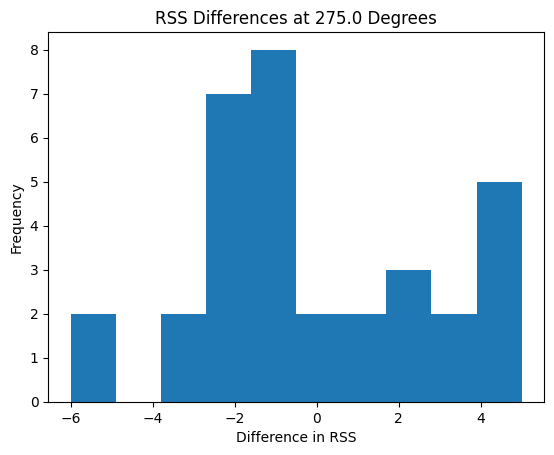

In [24]:
import math

ble_signals = Signals("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log", ['c',], angleOffset=0)

# --- plot a graph of RSS difference between packets at a given theta ---
theta = math.radians(275)

plt.title(f"RSS Differences at {math.degrees(theta)} Degrees")

draw_rss_difference_histogram(
    extract_every_rss_at_angle(ble_signals, theta)
)

# --- Plot graphs for every degree from 0-360 degrees ---

# plt.subplots(72, 5, figsize=(30, 5 * 72))
# plot_num = 1
#
# for theta in np.arange(0.0, 2 * math.pi, math.pi / 180):
#     plt.subplot(72, 5, plot_num)
#
#     draw_rss_difference_histogram(
#         extract_every_rss_at_angle(ble_signals, theta)
#     )
#
#     plot_num += 1
#
# plt.show()

# Draw Graph Combining RSS Differences for Every Angle

For every angle from 0-360 degrees, finds the difference in the RSS measurement between sequential packets for that angle, and then combines these differences into a single histogram.

Standardising angles and times (shifting by 0.00 degrees)
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39

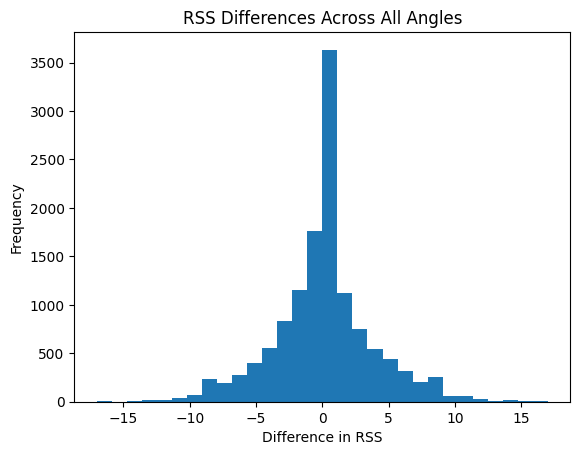

In [25]:
def draw_histogram_for_rss_at_every_angle(ble_signals :Signals, graph_title :str):
    """
    Find the RSS differences for every degree in 360 degrees and compile them into one histogram
    """
    all_rss_diffs = []

    for theta in np.arange(0.0, 2 * math.pi, math.pi / 180):
        rss_values = extract_every_rss_at_angle(ble_signals, theta)

        # get difference between RSSes
        for x in range(len(rss_values) - 1):
            all_rss_diffs.append(rss_values[x] - rss_values[x + 1])

    plt.hist(all_rss_diffs, bins=30)
    plt.title(graph_title)
    plt.ylabel("Frequency")
    plt.xlabel("Difference in RSS")

ble_signals = Signals("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/1.log", ['c',], angleOffset=0)
draw_histogram_for_rss_at_every_angle(ble_signals, "RSS Differences Across All Angles")

Same as the above, but for all the log files from the `TreeOcclusionProfiles` experiment.

Standardising angles and times (shifting by 0.00 degrees)
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS values found
0 RSS value

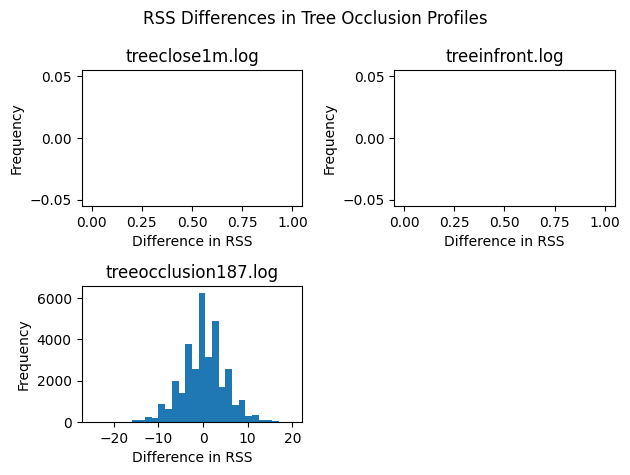

In [26]:
filenames = ["treeclose1m.log", "treeinfront.log", "treeocclusion187.log"]

for x in range(len(filenames)):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/Feb 18 2025 Field Trial/TreeOcclusionProfiles/{filenames[x]}", ['c',], angleOffset=0)

    plt.subplot(2, 2, x + 1)
    draw_histogram_for_rss_at_every_angle(ble_signals, filenames[x])

plt.suptitle("RSS Differences in Tree Occlusion Profiles")
plt.tight_layout()
plt.show()

Same as the above, but examining the complex paths within `March 26 2025 Field Trial/complexpath*` folders

Standardising angles and times (shifting by 0.00 degrees)
76 RSS values found
77 RSS values found
77 RSS values found
81 RSS values found
81 RSS values found
82 RSS values found
80 RSS values found
80 RSS values found
76 RSS values found
77 RSS values found
78 RSS values found
74 RSS values found
76 RSS values found
76 RSS values found
73 RSS values found
72 RSS values found
73 RSS values found
76 RSS values found
76 RSS values found
76 RSS values found
77 RSS values found
78 RSS values found
78 RSS values found
78 RSS values found
78 RSS values found
78 RSS values found
77 RSS values found
77 RSS values found
73 RSS values found
72 RSS values found
72 RSS values found
72 RSS values found
69 RSS values found
68 RSS values found
67 RSS values found
67 RSS values found
64 RSS values found
64 RSS values found
65 RSS values found
67 RSS values found
69 RSS values found
69 RSS values found
70 RSS values found
69 RSS values found
70 RSS values found
70 RSS values found
65 RSS values found
66

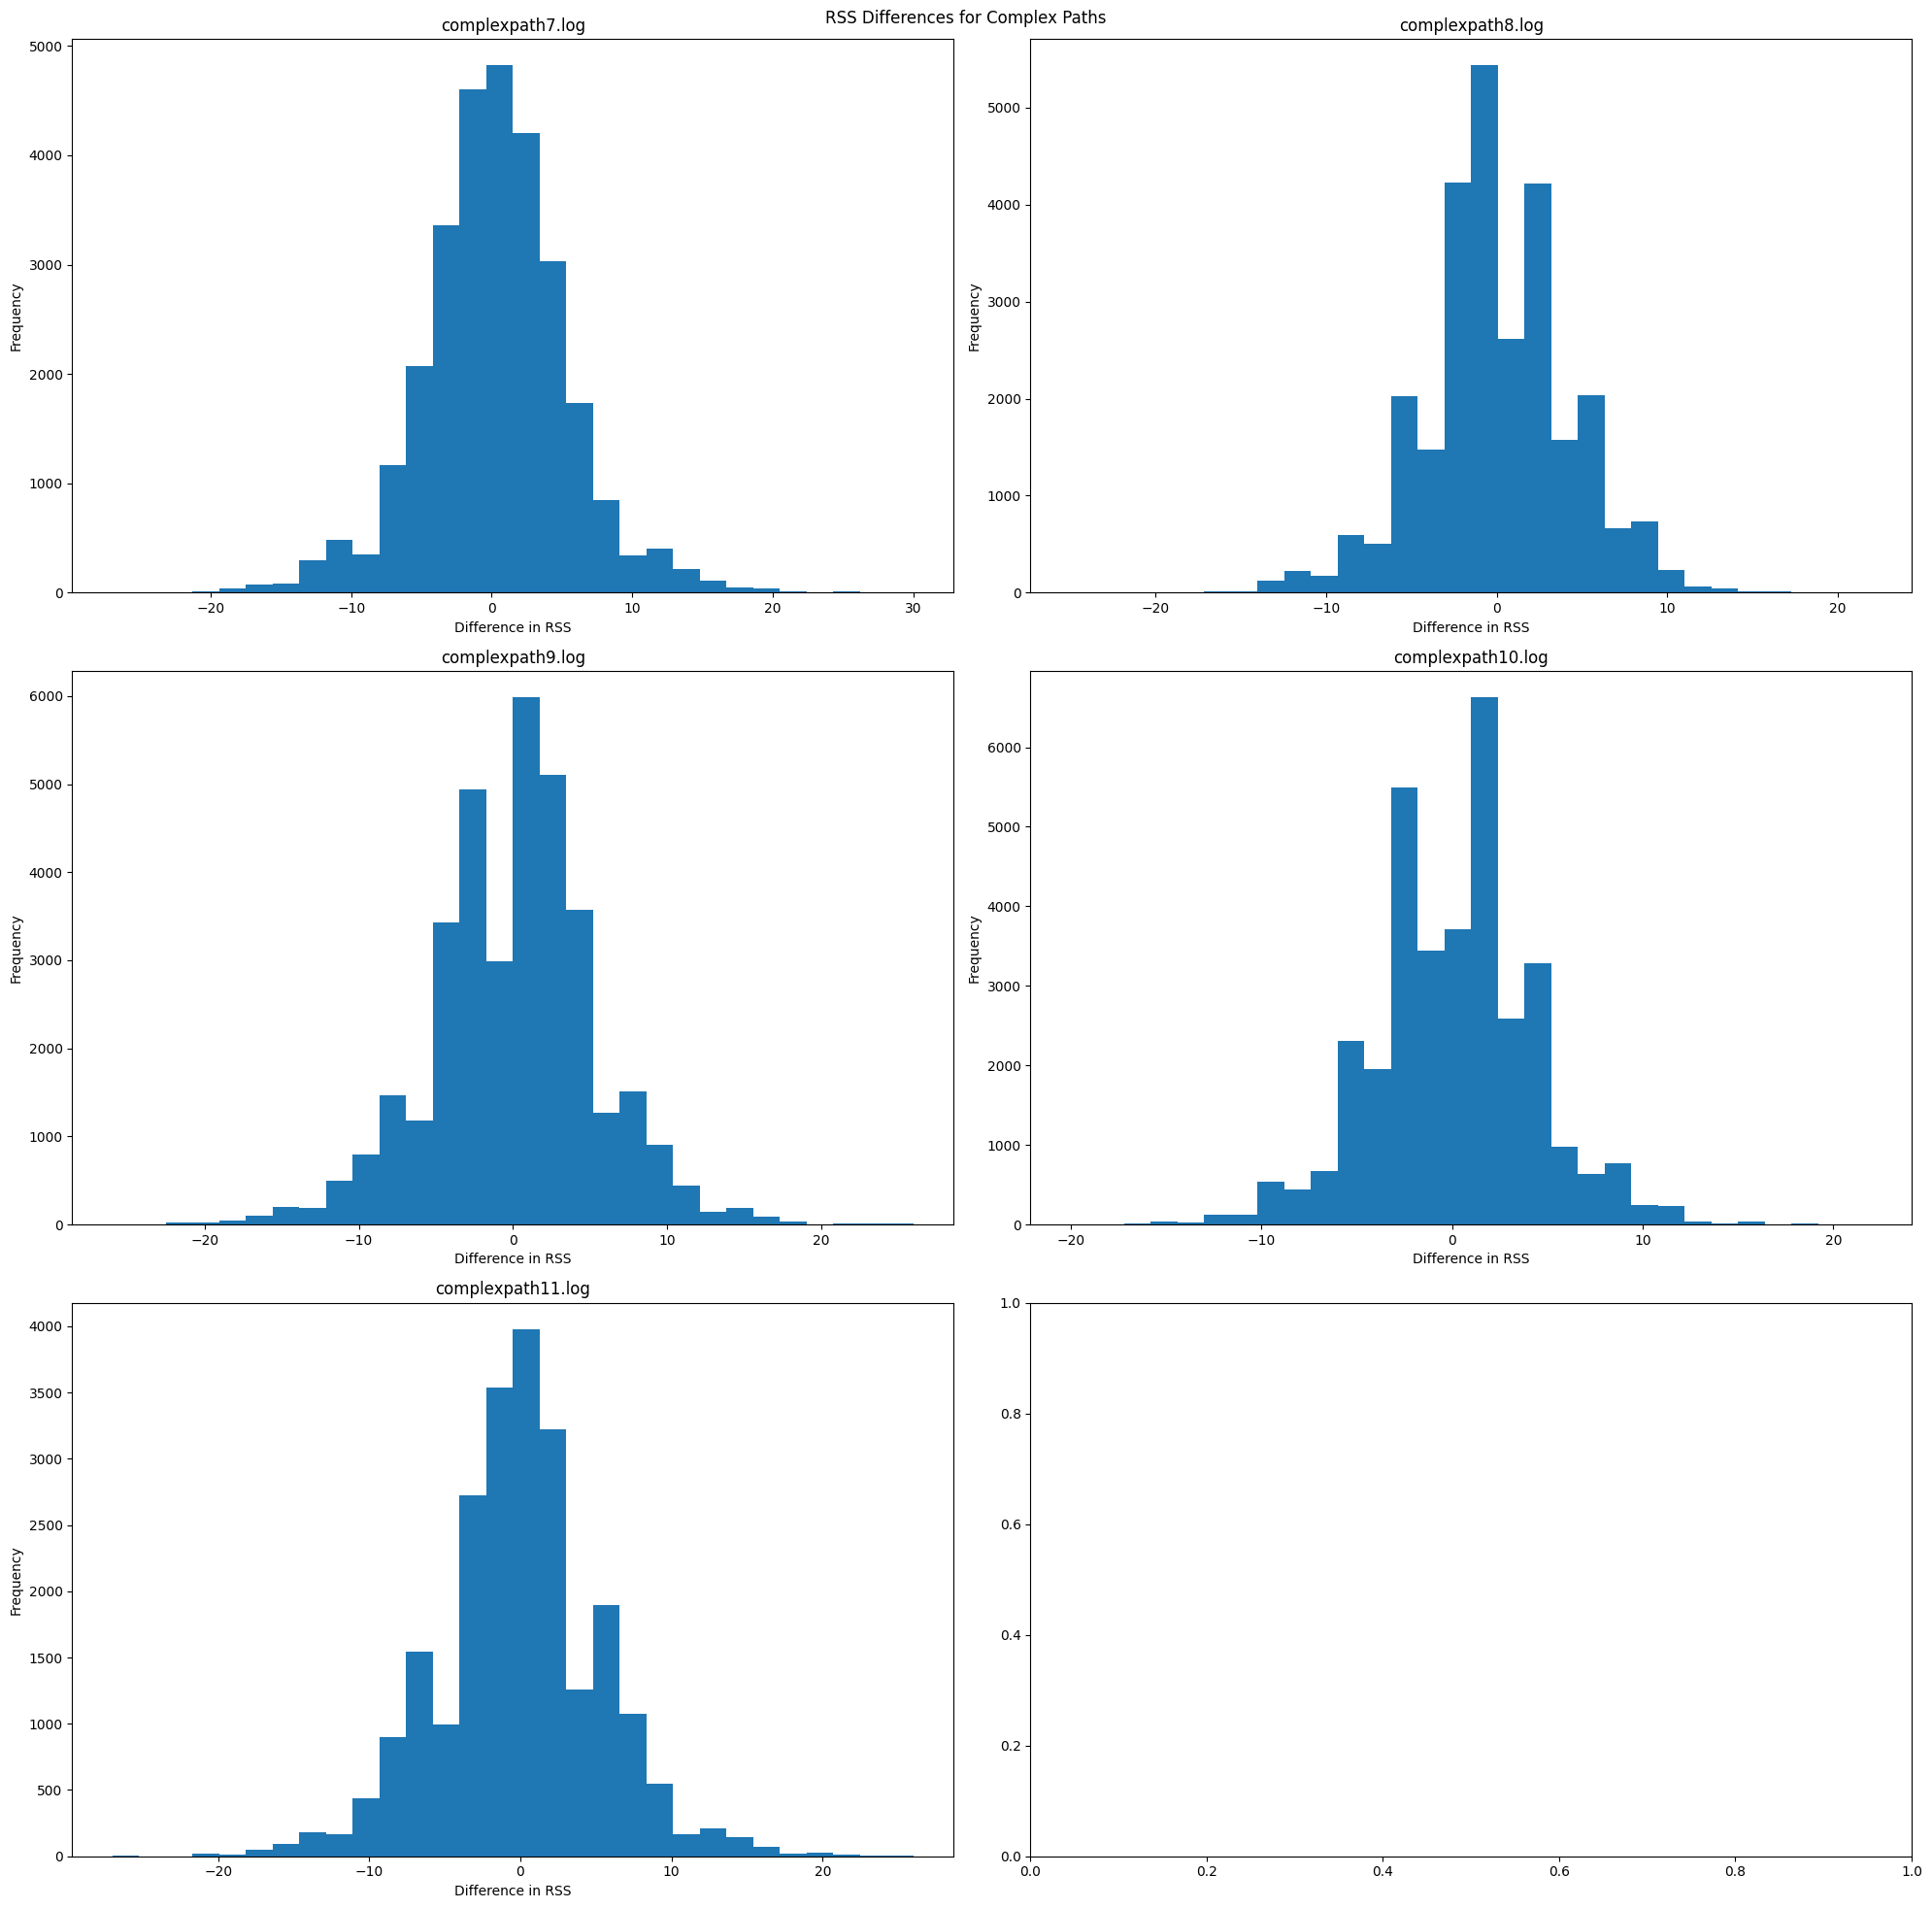

In [31]:
plt.subplots(3, 2, figsize=(20, 20))

for x in range(7, 12):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/complexpath{x}/complexpath{x}.log", ['c',], angleOffset=0)

    plt.subplot(3, 2, x - 6)
    draw_histogram_for_rss_at_every_angle(ble_signals, f"complexpath{x}.log")

plt.suptitle("RSS Differences for Complex Paths")
plt.tight_layout()
plt.show()

Same as the above, but for all of the straight paths in the `March 2 2025 Field Trial/straightpath*` folders

Standardising angles and times (shifting by 0.00 degrees)
24 RSS values found
24 RSS values found
25 RSS values found
27 RSS values found
27 RSS values found
27 RSS values found
28 RSS values found
28 RSS values found
27 RSS values found
27 RSS values found
28 RSS values found
28 RSS values found
30 RSS values found
30 RSS values found
30 RSS values found
31 RSS values found
31 RSS values found
31 RSS values found
31 RSS values found
31 RSS values found
31 RSS values found
31 RSS values found
30 RSS values found
31 RSS values found
31 RSS values found
32 RSS values found
31 RSS values found
31 RSS values found
30 RSS values found
30 RSS values found
30 RSS values found
29 RSS values found
29 RSS values found
29 RSS values found
28 RSS values found
28 RSS values found
28 RSS values found
28 RSS values found
29 RSS values found
29 RSS values found
28 RSS values found
29 RSS values found
29 RSS values found
29 RSS values found
28 RSS values found
28 RSS values found
26 RSS values found
27

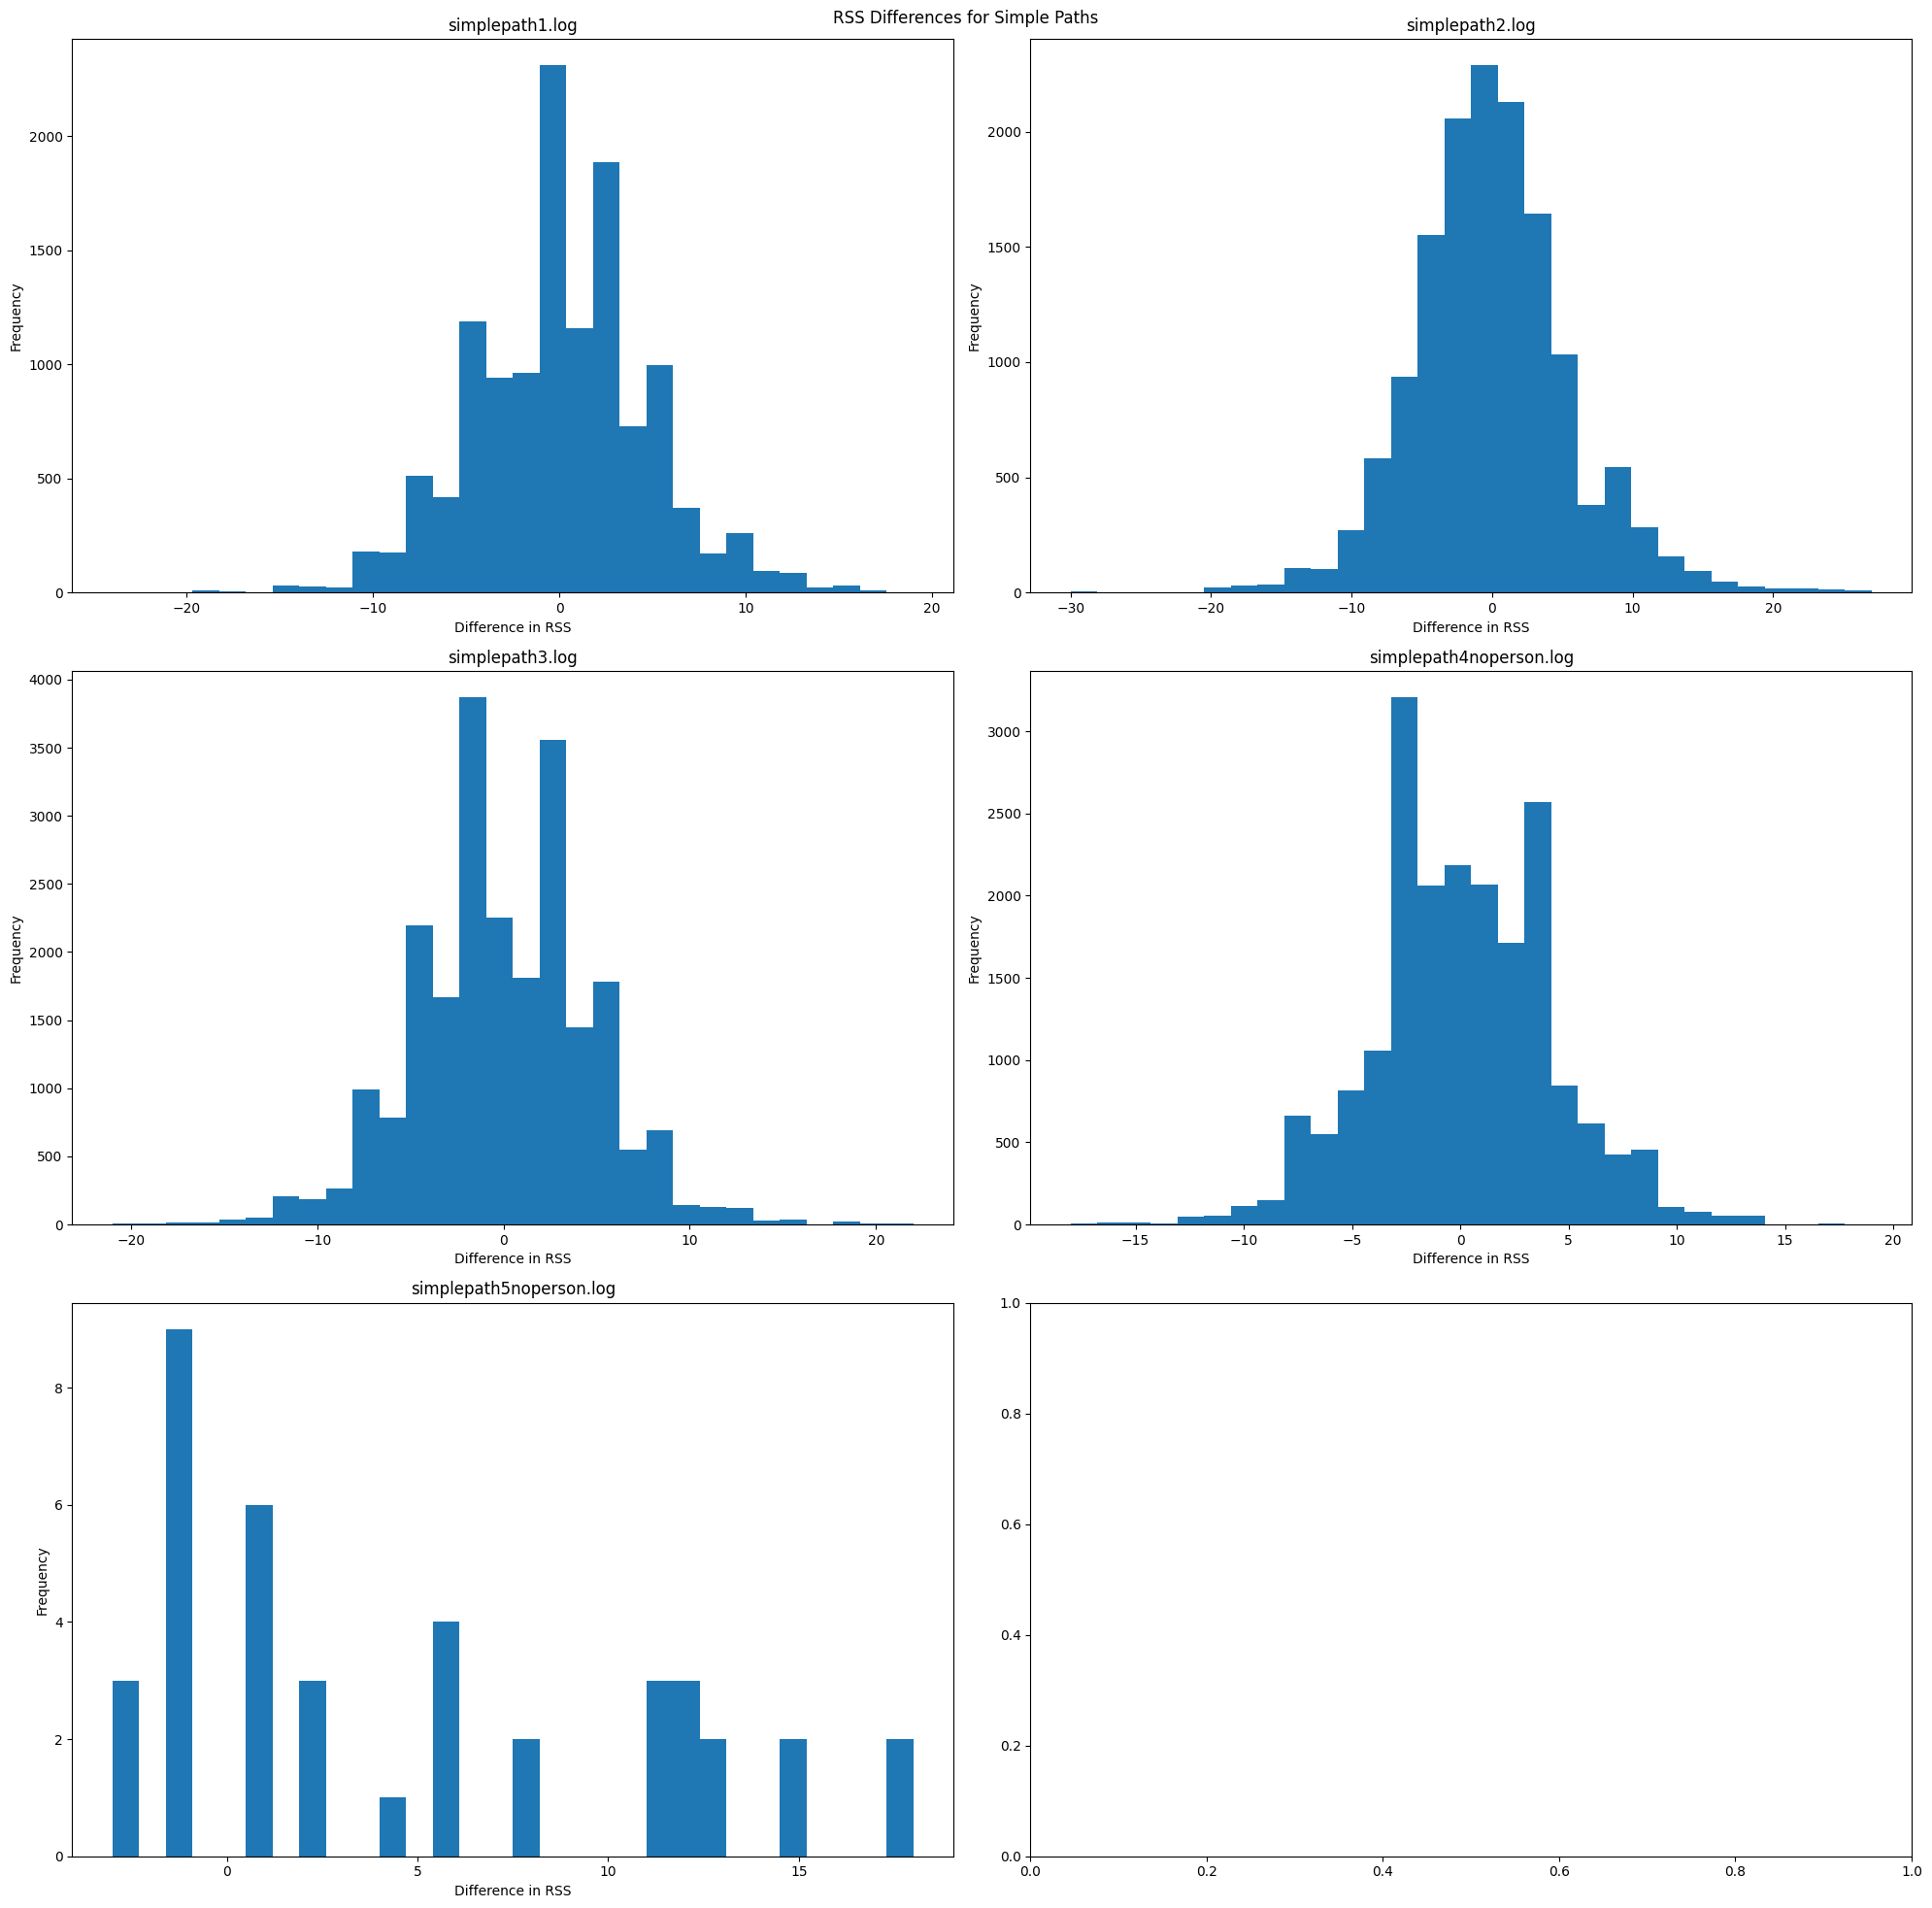

In [33]:
plt.subplots(3, 2, figsize=(20, 20))

# first three files with a similar naming scheme
for x in range(1, 4):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath{x}/straightpath{x}.log", ['c',], angleOffset=0)

    plt.subplot(3, 2, x)
    draw_histogram_for_rss_at_every_angle(ble_signals, f"simplepath{x}.log")

# last two files with a different naming scheme
for x in range(4, 6):
    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath{x}/straightpath{x}noperson.log", ['c',], angleOffset=0)

    plt.subplot(3, 2, x)
    draw_histogram_for_rss_at_every_angle(ble_signals, f"simplepath{x}noperson.log")

plt.suptitle("RSS Differences for Simple Paths")
plt.tight_layout()
plt.show()

# Draw a Graph of RSS Differences Between Every Angles Across Multiple Files

Does the same as the previous cell, but does this for every file in the `March 26 2025 Field Trial/Range Trials` folder. Combines all results into one large histogram.

Note that `6.log` causes an error so it is ignored.

Examining file 1.log
Standardising angles and times (shifting by 0.00 degrees)
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
39 RSS values found
3

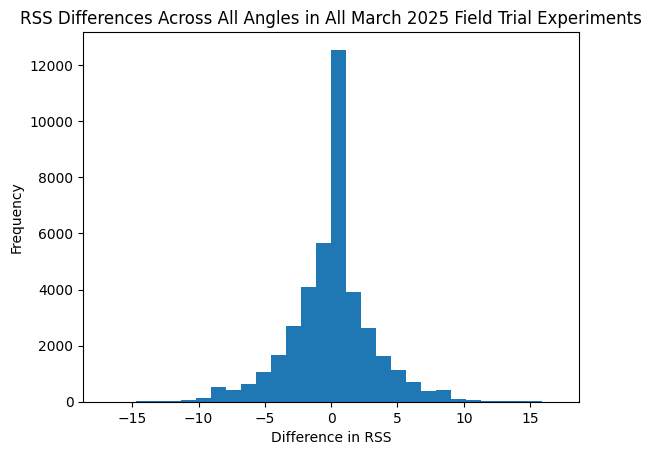

In [27]:
all_rss_diffs = []

# examine all 9 log files
for file_num in range (1, 9):
    print(f"Examining file {file_num}.log")

    # 6.log causes an error
    if file_num == 6:
        continue

    ble_signals = Signals(f"/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/{file_num}.log", ['c',], angleOffset=0)

    for theta in np.arange(0.0, 2 * math.pi, math.pi / 180):
        rss_values = extract_every_rss_at_angle(ble_signals, theta)

        # get difference between RSSes
        for x in range(len(rss_values) - 2):
            all_rss_diffs.append(rss_values[x] - rss_values[x + 1])

# draw the histogram
plt.hist(all_rss_diffs, bins=30)
plt.title("RSS Differences Across All Angles in March 2025 Field Trial Range Trials")
plt.ylabel("Frequency")
plt.xlabel("Difference in RSS")
plt.show()

## Create a Probability Distribution

From the data gathered in the above cell, calculate the mean and standard deviation (so variance) to represent that data as a normal distribution.

Mean: -0.0046
Standard Deviation: 3.22


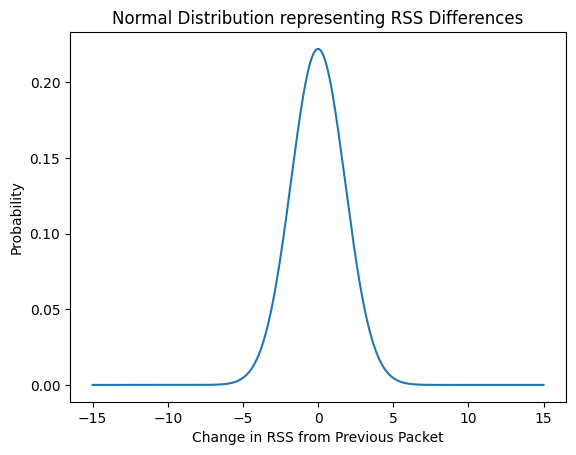

In [43]:
# find parameters used to make a normal distribution from this data
from scipy.stats import norm

mean = np.mean(all_rss_diffs)
standard_deviation = np.std(all_rss_diffs)
print(f"Mean: {mean:.3g}\nStandard Deviation: {standard_deviation:.3g}")

x_axis = np.arange(-15, 15, 0.01)

plt.ylabel("Probability")
plt.xlabel("Change in RSS from Previous Packet")
plt.title("Normal Distribution representing RSS Differences")
plt.plot(x_axis, norm.pdf(x_axis, mean, math.sqrt(standard_deviation)))
plt.show()